In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

In [3]:
test = pd.read_csv('test.csv')
train = pd.read_csv('train.csv')

In [ ]:
train.head()
train.isna().sum()
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3697 entries, 0 to 3696
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        3697 non-null   int64  
 1   ClientPeriod              3697 non-null   int64  
 2   MonthlySpending           3697 non-null   float64
 3   TotalSpent                3697 non-null   object 
 4   Sex                       3697 non-null   object 
 5   IsSeniorCitizen           3697 non-null   int64  
 6   HasPartner                3697 non-null   object 
 7   HasChild                  3697 non-null   object 
 8   HasPhoneService           3697 non-null   object 
 9   HasMultiplePhoneNumbers   3697 non-null   object 
 10  HasInternetService        3697 non-null   object 
 11  HasOnlineSecurityService  3697 non-null   object 
 12  HasOnlineBackup           3697 non-null   object 
 13  HasDeviceProtection       3697 non-null   object 
 14  HasTechS

In [12]:
target = train['Churn']
cat_cols = [
    'Sex',
    'IsSeniorCitizen',
    'HasPartner',
    'HasChild',
    'HasPhoneService',
    'HasMultiplePhoneNumbers',
    'HasInternetService',
    'HasOnlineSecurityService',
    'HasOnlineBackup',
    'HasDeviceProtection',
    'HasTechSupportAccess',
    'HasOnlineTV',
    'HasMovieSubscription',
    'HasContractPhone',
    'IsBillingPaperless',
    'PaymentMethod'
]
num_cols = [
    'ClientPeriod',
    'MonthlySpending',
    'TotalSpent'
]

In [38]:
for df in (train, test):
    df['TotalSpent'] = pd.to_numeric(df['TotalSpent'], errors='coerce')

train['TotalSpent'].fillna(train['TotalSpent'].median(), inplace=True)
test['TotalSpent'].fillna(train['TotalSpent'].median(), inplace=True)

/var/folders/37/_d6qphn11j54z96rn_6y5s440000gn/T/ipykernel_4366/2311353960.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['TotalSpent'].fillna(train['TotalSpent'].median(), inplace=True)
/var/folders/37/_d6qphn11j54z96rn_6y5s440000gn/T/ipykernel_4366/2311353960.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are

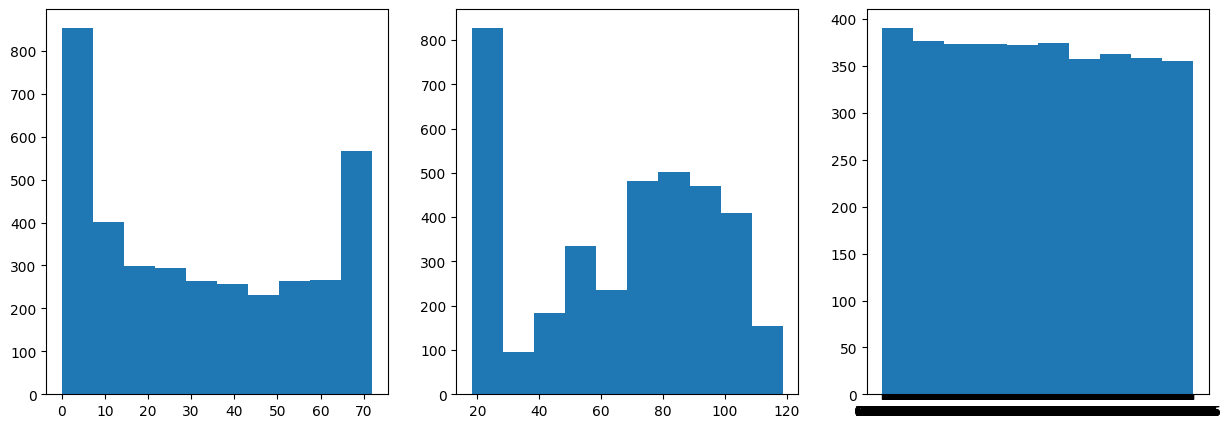

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].hist(train['ClientPeriod'])
axes[1].hist(train['MonthlySpending'])
axes[2].hist(train['TotalSpent'])
plt.show()


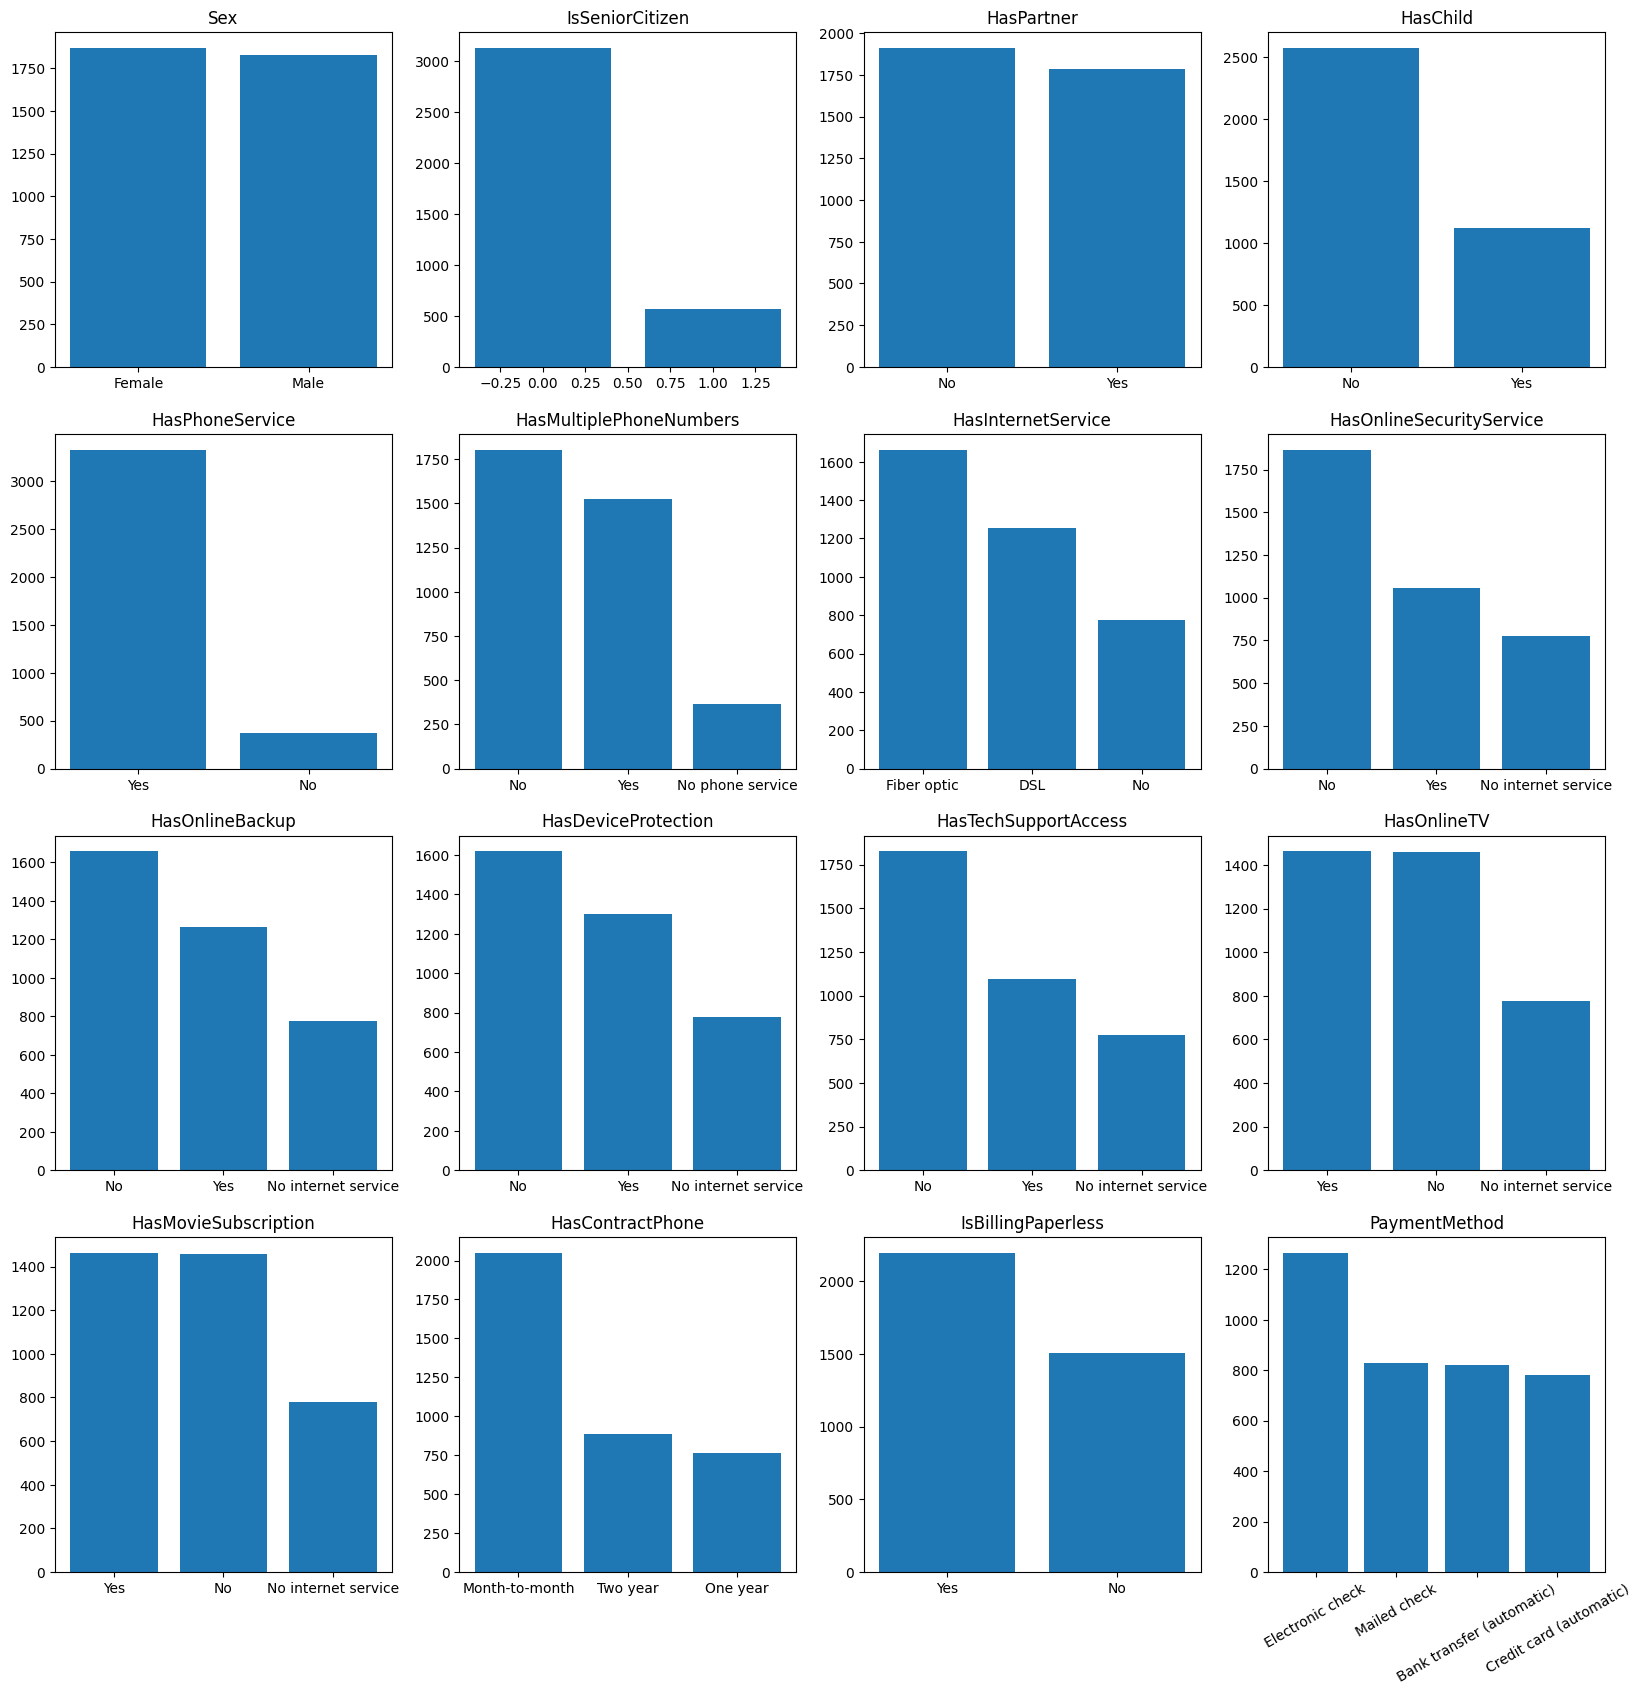

<Figure size 640x480 with 0 Axes>

In [27]:
fig, axes = plt.subplots(4, 4, figsize=(20, 20))
for i, cat in enumerate(cat_cols):
    cnt = train[cat].value_counts()
    ax = axes[i // 4, i % 4]
    ax.bar(cnt.index, cnt.values)
    ax.set_title(cat)
    if i == 15:
        ax.tick_params(axis='x', rotation=30)
plt.show()
plt.tight_layout()




In [28]:
target.value_counts()

Churn
0    2728
1     969
Name: count, dtype: int64

Classes are imbalanced

In [29]:
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder, OneHotEncoder
from sklearn.pipeline import make_pipeline

In [39]:
scaler = StandardScaler()
encoder = OneHotEncoder(sparse_output=False)

In [40]:
X_train, X_test, y_train, y_test = train_test_split(train.drop(columns=['Churn']), target, test_size=0.2, random_state=42)

In [41]:
encoder.fit(X_train[cat_cols])
X_train_cat = encoder.transform(X_train[cat_cols])
X_test_cat = encoder.transform(X_test[cat_cols])
X_train_num = scaler.fit_transform(X_train[num_cols])
X_test_num = scaler.transform(X_test[num_cols])
X_train_scaled = np.hstack([X_train_cat, X_train_num])
X_test_scaled = np.hstack([X_test_cat, X_test_num])

X_train.head()

,ID,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod
2887,2887,61,62.15,3778.85,Male,0,Yes,No,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Mailed check
2715,2715,6,74.40,434.10,Female,1,No,No,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,No,Electronic check
818,818,57,89.85,4925.35,Male,1,Yes,No,Yes,Yes,Fiber optic,No,Yes,No,No,No,Yes,Month-to-month,Yes,Electronic check
3560,3560,17,104.20,1743.50,Female,0,Yes,Yes,Yes,Yes,Fiber optic,Yes,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check
2578,2578,48,39.40,1978.65,Female,0,Yes,Yes,No,No phone service,DSL,Yes,Yes,No,Yes,No,No,Two year,No,Mailed check
